# Desarrollo de un flujo de Procesamiento de Datos y Analisis en un entorno de simulacion profesional
#### Caso de estudio: Análisis de datos de urgencias no procesados
Grupo_2 - integrantes:
- Daniela Zarate
- Gabriel Toledo

## Descripcion de un supuesto contexto, respecto al dataset entregado
Este trabajo se centra en la aplicación de técnicas de manipulación, limpieza y transformación de datos, generando insights y dejando la 
información lista para futuras etapas de modelado.

Al analizar el archivo entregado 'urgencias_noprocesados_grupo02.csv', podemos levantar un primer contexto general sobre el dataset. Este 
archivo contiene datos relacionados con instituciones de salud en Chile y sus atenciones de urgencias médicas. Se analizara un registro detallado de antecedentes 
de urgencia respiratoria durante el periodo 2023-2025.    

El desafio consiste en transformar un dataset "sucio", caracterizado por inconsistencias en diagnósticos (mal tipeados), fecha sin formato y 
valores nulos en un activo estrategico que permita entender la relación entre la gravedad clínica (Triage), los costos operativos y la demanda 
epidemiológica por grupos etarios. Mediante la aplicación de un flujo profesional de ETL (Extracción, Transformación y Carga) y Análisis 
Exploratorio (EDA), el objetivo es generar insights que permitan a los directivos hospitalarios anticipar picos estacionales de enfermedades 
como la Influenza o el COVID-19 y optimizar la distribución de recursos financieros y humanos en las regiones afectadas.

## Preparación para el trabajo con el dataset
**Dataset:** `urgencias_noprocesados_grupo02.csv`  

En esta sección se prepara el hambiente para el trabajo a realizar, llevaremos a cabo la visualización inicial del dataset ya subido a memoria 
como DataFrame y se crea una copia para trabajar sin modificar el dataset original. Además, se declara comentado el proceso de guardado 
intermedio del DataFrame como datasets trabajados (para casos de procesos largos o complejos).

- Levantamos el dataset para su análisis inicial.
- Creamos una copia del dataset para trabajar, preservando el original.
- (Comentado) Guardamos el dataset editado en un directorio intermedio, aplicable en procesos largos.

### Carga de Librerías y configuración

In [37]:
# importamos liberias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import unicodedata
import re
import os

# configuramos pandas para mostrar sin perdida de información
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

print("Librerias importadas y configuracion lista")

Librerias importadas y configuracion lista


### Carga de datos y visualización inicial
En esta sección se realiza la carga del dataset original en un DataFrame de pandas.

In [39]:
# Definir ruta de dataset original en carpeta ./raw/
PATH_RAW = '../data/raw/urgencias_noprocesados_grupo02.csv'

# Carga el dataset original en un DataFrame
DF_ORIGINAL = pd.read_csv(PATH_RAW ,sep=';')

# Crea copia del dataframe para trabajar
df = DF_ORIGINAL.copy()

# Mostramos las primeras 4 filas del dataframe, verificamos su contenido y carga
df.head(4)

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,NivelAtencion,TipoUrgencia,Latitud,Longitud,NivelComplejidad,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
0,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,1,Influenza y neumonia,201,19,21,27,87,47,02-01-2023,M,C5,85725.0
1,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,2,Infeccion respiratoria aguda alta,193,14,25,30,106,18,02-01-2023,M,C3,85238.0
2,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,3,Bronquitis/Bronquiolitis aguda,94,18,19,23,28,6,02-01-2023,M,C3,100570.0
3,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,4,Crisis asmática,74,3,11,17,35,8,02-01-2023,M,C4,72941.0


In [ ]:
# Identificamos el tamaño del DataFrame
df_tamaño = df.shape
print("#################### Tamaño del DataFrame ####################")
print("Número de filas:", df_tamaño[0])
print("Número de columnas:", df_tamaño[1])

#################### Tamaño del DataFrame ####################
Número de filas: 4742
Número de columnas: 29


In [59]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4742 entries, 0 to 4741
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EstablecimientoCodigo      4742 non-null   int64  
 1   EstablecimientoGlosa       4742 non-null   str    
 2   RegionCodigo               4742 non-null   int64  
 3   RegionGlosa                4742 non-null   str    
 4   ComunaCodigo               4742 non-null   int64  
 5   ComunaGlosa                4742 non-null   str    
 6   ServicioSaludCodigo        4742 non-null   int64  
 7   ServicioSaludGlosa         4742 non-null   str    
 8   TipoEstablecimiento        4742 non-null   str    
 9   DependenciaAdministrativa  4716 non-null   str    
 10  NivelAtencion              4742 non-null   str    
 11  TipoUrgencia               4728 non-null   str    
 12  Latitud                    4722 non-null   float64
 13  Longitud                   4731 non-null   float64
 14  Niv

Identificamos las variables con valores nulos.
En una primera visualización del dataset, se identifican el total de filas 4742 y columnas 29.
| # | Column | Non-Null Count | Dtype |
| :--- | :--- | :--- | :--- |
| 9 | DependenciaAdministrativa | 4716 non-null | str |
| 11 | TipoUrgencia | 4728 non-null | str |
| 12 | Latitud | 4722 non-null | float64 |
| 13 | Longitud | 4731 non-null | float64 |
| 14 | NivelComplejidad | 4718 non-null | str |

Con esta información podemos comparar los numeros de filas no nulas con el total de filas para identificar la cantidad de valores nulos en cada variable.

In [60]:
display(df.describe(include="all").T.head(15))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EstablecimientoCodigo,4742.0,NaN,NaN,NaN,283497.069802,314292.144079,110901.0,130215.0,131450.0,131622.0,910333.0
EstablecimientoGlosa,4742,10,Hospital Regional de Temuco,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegionCodigo,4742.0,NaN,NaN,NaN,10.995782,3.578508,5.0,9.0,13.0,13.0,15.0
RegionGlosa,4742,4,Metropolitana,1893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ComunaCodigo,4742.0,NaN,NaN,NaN,11106.171236,3580.199586,5109.0,9101.0,13115.0,13126.0,15101.0
ComunaGlosa,4742,5,Temuco,952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ServicioSaludCodigo,4742.0,NaN,NaN,NaN,7.20329,4.022926,1.0,5.0,8.0,9.0,13.0
ServicioSaludGlosa,4742,5,Servicio de Salud Araucania Sur,952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TipoEstablecimiento,4742,2,Hospital,2849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DependenciaAdministrativa,4716,2,Servicio de Salud,2832,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
print("Columnas:")
for col in df.columns:
    print("-", col)

Columnas:
- EstablecimientoCodigo
- EstablecimientoGlosa
- RegionCodigo
- RegionGlosa
- ComunaCodigo
- ComunaGlosa
- ServicioSaludCodigo
- ServicioSaludGlosa
- TipoEstablecimiento
- DependenciaAdministrativa
- NivelAtencion
- TipoUrgencia
- Latitud
- Longitud
- NivelComplejidad
- Anio
- SemanaEstadistica
- OrdenCausa
- Causa
- NumTotal
- NumMenor1Anio
- Num1a4Anios
- Num5a14Anios
- Num15a64Anios
- Num65oMas
- FechaAtencionTexto
- SexoPaciente
- PrioridadTriage
- CostoAtencionCLP


In [62]:
audit_resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "n_unicos": df.nunique(dropna=True)
}).sort_values(["pct_nulos", "nulos"], ascending=False)

audit_resumen

,dtype,nulos,pct_nulos,n_unicos
DependenciaAdministrativa,str,26,0.55,2
NivelComplejidad,str,24,0.51,2
Latitud,float64,20,0.42,5
FechaAtencionTexto,str,18,0.38,312
SexoPaciente,str,18,0.38,6
PrioridadTriage,str,18,0.38,10
CostoAtencionCLP,float64,18,0.38,4570
TipoUrgencia,str,14,0.30,13
Longitud,float64,11,0.23,5
EstablecimientoCodigo,int64,0,0.00,5


In [19]:
print(df.isnull().sum())

EstablecimientoCodigo         0
EstablecimientoGlosa          0
RegionCodigo                  0
RegionGlosa                   0
ComunaCodigo                  0
ComunaGlosa                   0
ServicioSaludCodigo           0
ServicioSaludGlosa            0
TipoEstablecimiento           0
DependenciaAdministrativa    26
NivelAtencion                 0
TipoUrgencia                 14
Latitud                      20
Longitud                     11
NivelComplejidad             24
Anio                          0
SemanaEstadistica             0
OrdenCausa                    0
Causa                         0
NumTotal                      0
NumMenor1Anio                 0
Num1a4Anios                   0
Num5a14Anios                  0
Num15a64Anios                 0
Num65oMas                     0
FechaAtencionTexto           18
SexoPaciente                 18
PrioridadTriage              18
CostoAtencionCLP             18
dtype: int64


In [ ]:
# Verificar duplicados
print(df.duplicated().sum())

37


In [27]:
# listar duplicados
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10)

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
300,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,203,14,17,29,91,52,13-03-2023,F,C3,64282.0
4716,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,203,14,17,29,91,52,13-03-2023,F,C3,64282.0
361,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,169,13,29,29,68,30,27-03-2023,F,C3,65433.0
4719,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,169,13,29,29,68,30,27-03-2023,F,C3,65433.0
663,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,240,11,28,63,107,31,05-06-2023,F,C3,65998.0
4714,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,240,11,28,63,107,31,05-06-2023,F,C3,65998.0
2282,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,176,49,49,37,28,13,17-06-2024,F,C5,92981.0
4705,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,176,49,49,37,28,13,17-06-2024,F,C5,92981.0
2914,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,164,9,7,13,65,70,11.11.24,M,C2,105275.0
4707,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,164,9,7,13,65,70,11.11.24,M,C2,105275.0


In [28]:
# mostrar una vez cada duplicado
df[df.duplicated(keep='first')].sort_values(by=df.columns.tolist()).head(10)

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
4716,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,203,14,17,29,91,52,13-03-2023,F,C3,64282.0
4719,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,169,13,29,29,68,30,27-03-2023,F,C3,65433.0
4714,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,240,11,28,63,107,31,05-06-2023,F,C3,65998.0
4705,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,176,49,49,37,28,13,17-06-2024,F,C5,92981.0
4707,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,164,9,7,13,65,70,11.11.24,M,C2,105275.0
4737,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,152,6,18,19,72,37,21-04-2025,F,C3,108901.0
4721,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,...,210,14,25,36,90,45,03-11-2025,M,C4,109687.0
4730,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,106,11,13,19,42,21,09-10-2023,F,C3,70514.0
4739,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,38,0,1,3,14,20,22-01-2024,M,C5,83653.0
4741,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,118,9,11,21,51,26,05-02-2024,M,C2,69562.0


### Utilizamos esta sección en caso de que el proceso o transformación de datos sea largo o complejo

In [4]:
##
# Guardamos parte del dataset editado (punto intermedio durante procesos largos)
# Aseguramos la existencia del directorio intermedio de trabajo
##
# PATH_INTERIM = '../data/interim/COPIA_urgencias_noprocesados_grupo02.csv'
# os.makedirs('../data/interim', exist_ok=True)
# df.to_csv(PATH_INTERIM, index=False)

## --- IGNORE ---

In [10]:
print(df.shape)        # filas, columnas
print(df.columns)      # nombres de columnas
print(df.dtypes)       # tipos de datos

(4742, 29)
Index(['EstablecimientoCodigo', 'EstablecimientoGlosa', 'RegionCodigo',
       'RegionGlosa', 'ComunaCodigo', 'ComunaGlosa', 'ServicioSaludCodigo',
       'ServicioSaludGlosa', 'TipoEstablecimiento',
       'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'Latitud',
       'Longitud', 'NivelComplejidad', 'Anio', 'SemanaEstadistica',
       'OrdenCausa', 'Causa', 'NumTotal', 'NumMenor1Anio', 'Num1a4Anios',
       'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'FechaAtencionTexto',
       'SexoPaciente', 'PrioridadTriage', 'CostoAtencionCLP'],
      dtype='str')
EstablecimientoCodigo          int64
EstablecimientoGlosa             str
RegionCodigo                   int64
RegionGlosa                      str
ComunaCodigo                   int64
ComunaGlosa                      str
ServicioSaludCodigo            int64
ServicioSaludGlosa               str
TipoEstablecimiento              str
DependenciaAdministrativa        str
NivelAtencion                    str
Tip

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4742 entries, 0 to 4741
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EstablecimientoCodigo      4742 non-null   int64  
 1   EstablecimientoGlosa       4742 non-null   str    
 2   RegionCodigo               4742 non-null   int64  
 3   RegionGlosa                4742 non-null   str    
 4   ComunaCodigo               4742 non-null   int64  
 5   ComunaGlosa                4742 non-null   str    
 6   ServicioSaludCodigo        4742 non-null   int64  
 7   ServicioSaludGlosa         4742 non-null   str    
 8   TipoEstablecimiento        4742 non-null   str    
 9   DependenciaAdministrativa  4716 non-null   str    
 10  NivelAtencion              4742 non-null   str    
 11  TipoUrgencia               4728 non-null   str    
 12  Latitud                    4722 non-null   float64
 13  Longitud                   4731 non-null   float64
 14  Niv

In [12]:
df.sample(5)

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
2383,131450,SAR La Reina,13,Metropolitana,13115,La Reina,9,Servicio de Salud Metropolitano Oriente,Centro de Salud,Municipal,...,64,3,9,12,31,9,08-07-2024,M,C2,110503.0
3493,131450,SAR La Reina,13,Metropolitana,13115,La Reina,9,Servicio de Salud Metropolitano Oriente,Centro de Salud,Municipal,...,133,7,19,25,62,20,24-03-2025,F,C2,78940.0
2320,130215,Hospital Dr. Gustavo Fricke,5,Valparaiso,5109,Vina del Mar,5,Servicio de Salud Vina del Mar-Quillota,Hospital,Servicio de Salud,...,245,10,10,20,78,127,24-06-2024,F,C3,126226.0
55,910333,Hospital Regional de Temuco,9,La Araucania,9101,Temuco,13,Servicio de Salud Araucania Sur,Hospital,Servicio de Salud,...,49,968,4,9,24,8,09-01-2023,F,C2,137169.0
2840,131622,SAPU Pudahuel Sur,13,Metropolitana,13126,Pudahuel,8,Servicio de Salud Metropolitano Occidente,Centro de Salud,Municipal,...,111,38,24,18,26,5,21-10-2024,M,C3,140376.0


In [13]:
df.describe()

,EstablecimientoCodigo,RegionCodigo,ComunaCodigo,ServicioSaludCodigo,Latitud,Longitud,Anio,SemanaEstadistica,OrdenCausa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,CostoAtencionCLP
count,4742.000000,4742.000000,4742.000000,4742.000000,4722.000000,4731.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4.724000e+03
mean,283497.069802,10.995782,11106.171236,7.203290,-314.253063,-711.591901,2024.001898,26.519823,3.497891,148.006537,17.333404,20.788697,27.829608,59.697385,30.539646,9.997439e+04
std,314292.144079,3.578508,3580.199586,4.022926,68.130193,8.330590,0.815762,15.015647,1.707057,108.006469,55.942957,53.947470,50.556198,65.509901,60.108655,5.108499e+04
min,110901.000000,5.000000,5109.000000,1.000000,-387.397000,-725.984000,2023.000000,1.000000,1.000000,17.000000,0.000000,0.000000,0.000000,6.000000,0.000000,1.500000e+04
25%,130215.000000,9.000000,9101.000000,5.000000,-334.429000,-715.518000,2023.000000,14.000000,2.000000,93.000000,5.000000,8.000000,13.000000,34.000000,10.000000,7.929600e+04
50%,131450.000000,13.000000,13115.000000,8.000000,-334.372000,-707.766000,2024.000000,27.000000,3.000000,138.000000,9.000000,15.000000,23.000000,53.000000,20.000000,9.834500e+04
75%,131622.000000,13.000000,13126.000000,9.000000,-330.245000,-705.477000,2025.000000,40.000000,5.000000,188.000000,16.000000,24.000000,36.000000,76.000000,38.000000,1.171650e+05
max,910333.000000,15.000000,15101.000000,13.000000,-184.783000,-703.126000,2025.000000,52.000000,6.000000,2737.000000,2225.000000,1764.000000,1507.000000,1607.000000,1584.000000,1.722934e+06


In [7]:
display(df[['EstablecimientoCodigo','RegionCodigo','ComunaCodigo','ServicioSaludCodigo']].describe())

,EstablecimientoCodigo,RegionCodigo,ComunaCodigo,ServicioSaludCodigo
count,4742.000000,4742.000000,4742.000000,4742.000000
mean,283497.069802,10.995782,11106.171236,7.203290
std,314292.144079,3.578508,3580.199586,4.022926
min,110901.000000,5.000000,5109.000000,1.000000
25%,130215.000000,9.000000,9101.000000,5.000000
50%,131450.000000,13.000000,13115.000000,8.000000
75%,131622.000000,13.000000,13126.000000,9.000000
max,910333.000000,15.000000,15101.000000,13.000000


En esta parte podemos aprecia el numero de filas y columnas que se encuentren vacias en datates ya sea datos faltantes, null,NULL,nan,NAN,none, None, vacio, Vacío, VACIO, vacía, Vacía, VACÍA, vacíos, Vacíos, VACÍOS. Para poder tener una mejor visualizacion estadistica se muestran en porcentajes los datos faltantes en cada columna.

In [64]:
import pandas as pd
import csv

path = "../data/raw/urgencias_noprocesados_grupo02.csv"

# Detectar separador
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    sample = f.read(10000)
sep = csv.Sniffer().sniff(sample, delimiters=";,\t|").delimiter

na_tokens = ["", " ", "null", "NULL", "Null", "nan", "NaN", "NAN", "none", "None", "NONE", "n/a", "N/A"]
df = pd.read_csv(path, sep=sep, na_values=na_tokens, keep_default_na=True)

missing = df.isna().sum().sort_values(ascending=False)
resumen = pd.DataFrame({
    "faltantes": missing,
    "porcentaje_%": (missing / len(df) * 100).round(2)
})
resumen = resumen[resumen["faltantes"] > 0]

display(resumen)
print("Total faltantes:", int(df.isna().sum().sum()))
print("Filas con faltantes:", int(df.isna().any(axis=1).sum()))

,faltantes,porcentaje_%
DependenciaAdministrativa,26,0.55
NivelComplejidad,24,0.51
Latitud,20,0.42
SexoPaciente,18,0.38
PrioridadTriage,18,0.38
CostoAtencionCLP,18,0.38
FechaAtencionTexto,18,0.38
TipoUrgencia,14,0.30
Longitud,11,0.23


Total faltantes: 167
Filas con faltantes: 137


* Analisis de grafico de barras
 - con esto se buscamos poder visualizar los valores faltantes en cada columna, para esto se utiliza un grafico de barras donde se muestra el porcentaje de datos faltantes en cada columna, esto nos permite identificar cuales son las columnas que tienen mayor cantidad de datos faltantes y poder tomar decisiones sobre como manejar esos datos faltantes, ya sea eliminando las filas que contienen esos datos faltantes o imputando esos datos faltantes con algun valor estadistico como la media, mediana o moda.

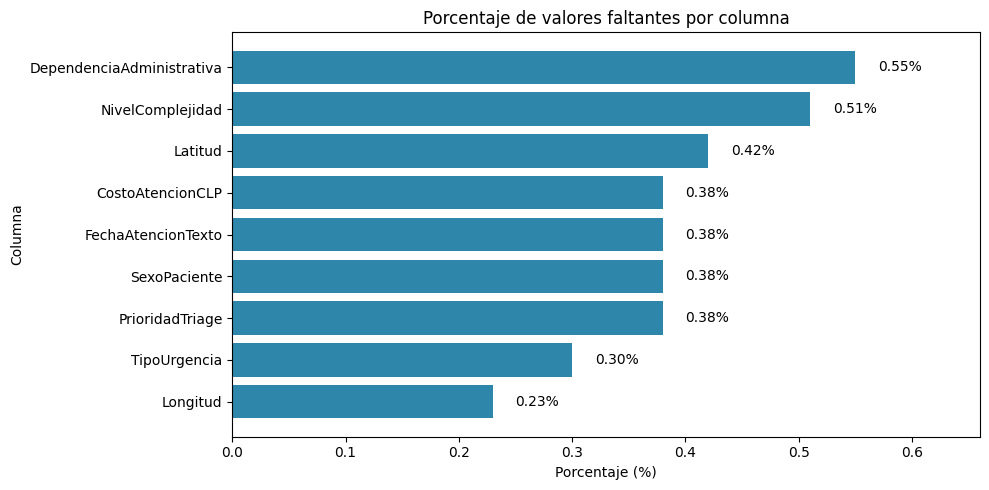

In [ ]:
import matplotlib.pyplot as plt

# Si 'resumen' viene del paso anterior:
# columnas: ['faltantes', 'porcentaje_%'] e índice = nombre de columna
resumen_plot = resumen.sort_values("porcentaje_%", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(resumen_plot.index, resumen_plot["porcentaje_%"], color="#2E86AB")

# Etiquetas de porcentaje al final de cada barra
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va="center")

plt.title("Porcentaje de valores faltantes por columna")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Columna")
plt.xlim(0, max(resumen_plot["porcentaje_%"]) * 1.2)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("urgencias_noprocesados_grupo02.csv", sep=";")

por_region = (
    df.groupby(["RegionCodigo", "RegionGlosa"])["EstablecimientoCodigo"]
      .nunique()
      .reset_index(name="n_establecimientos")
      .sort_values("n_establecimientos", ascending=False)
)

por_comuna = (
    df.groupby(["ComunaCodigo", "ComunaGlosa"])["EstablecimientoCodigo"]
      .nunique()
      .reset_index(name="n_establecimientos")
      .sort_values("n_establecimientos", ascending=False)
)

por_region_comuna = (
    df.groupby(["RegionCodigo", "RegionGlosa", "ComunaCodigo", "ComunaGlosa"])["EstablecimientoCodigo"]
      .nunique()
      .reset_index(name="n_establecimientos")
      .sort_values(["RegionCodigo", "n_establecimientos"], ascending=[True, False])
)

display(por_region)
display(por_comuna)
display(por_region_comuna)

,RegionCodigo,RegionGlosa,n_establecimientos
2,13,Metropolitana,2
0,5,Valparaiso,1
1,9,La Araucania,1
3,15,Arica y Parinacota,1


,ComunaCodigo,ComunaGlosa,n_establecimientos
0,5109,Vina del Mar,1
1,9101,Temuco,1
2,13115,La Reina,1
3,13126,Pudahuel,1
4,15101,Arica,1


,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,n_establecimientos
0,5,Valparaiso,5109,Vina del Mar,1
1,9,La Araucania,9101,Temuco,1
2,13,Metropolitana,13115,La Reina,1
3,13,Metropolitana,13126,Pudahuel,1
4,15,Arica y Parinacota,15101,Arica,1


## Comparacion: establecimientos unicos vs cantidad de registros
En estas tablas y graficos se comparan dos metricas:
- `establecimientos_unicos`: numero de codigos de establecimiento distintos (`nunique`).
- `registros`: cantidad total de filas por grupo (`count`).

Comparacion por region


,RegionCodigo,RegionGlosa,establecimientos_unicos,registros
2,13,Metropolitana,2,1893
0,5,Valparaiso,1,949
1,9,La Araucania,1,952
3,15,Arica y Parinacota,1,948


Comparacion por comuna


,ComunaCodigo,ComunaGlosa,establecimientos_unicos,registros
0,5109,Vina del Mar,1,949
1,9101,Temuco,1,952
2,13115,La Reina,1,945
3,13126,Pudahuel,1,948
4,15101,Arica,1,948


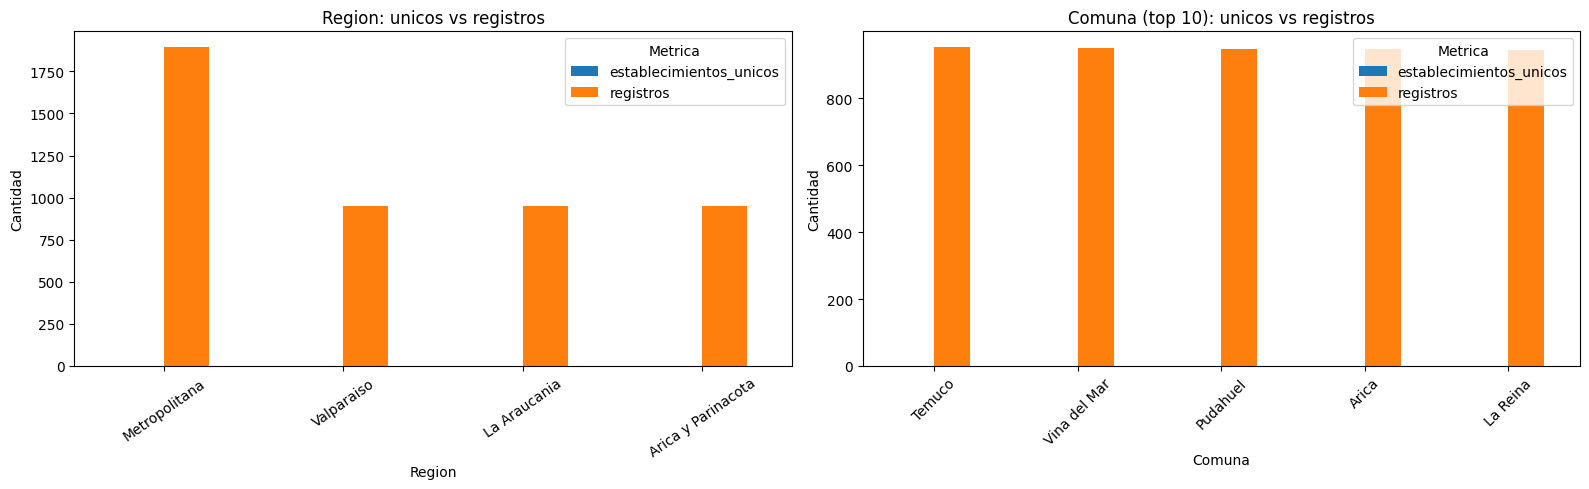

In [ ]:
import matplotlib.pyplot as plt

# Base de datos
if 'df' not in globals():
    df = pd.read_csv("urgencias_noprocesados_grupo02.csv", sep=";")

# 1) Comparacion por REGION
comp_region = (
    df.groupby(["RegionCodigo", "RegionGlosa"])['EstablecimientoCodigo']
      .agg(establecimientos_unicos='nunique', registros='count')
      .reset_index()
      .sort_values('establecimientos_unicos', ascending=False)
)

# 2) Comparacion por COMUNA
comp_comuna = (
    df.groupby(["ComunaCodigo", "ComunaGlosa"])['EstablecimientoCodigo']
      .agg(establecimientos_unicos='nunique', registros='count')
      .reset_index()
      .sort_values('establecimientos_unicos', ascending=False)
)

print('Comparacion por region')
display(comp_region)
print('Comparacion por comuna')
display(comp_comuna)

# Graficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Region: barras agrupadas
plot_region = comp_region.set_index('RegionGlosa')[["establecimientos_unicos", "registros"]]
plot_region.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Region: unicos vs registros')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Metrica')

# Comuna: top 10 por registros para lectura mas clara
top_comuna = comp_comuna.sort_values('registros', ascending=False).head(10)
plot_comuna = top_comuna.set_index('ComunaGlosa')[["establecimientos_unicos", "registros"]]
plot_comuna.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Comuna (top 10): unicos vs registros')
axes[1].set_xlabel('Comuna')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Metrica')

plt.tight_layout()
plt.show()